# Module 2 · Session 1 — Lab Notebook
## Transformer Fundamentals: Visualizing Attention

**Course:** Generative & Agentic AI Systems
**Time:** ~45 minutes (in-session) · also used for this session's assignment

---

### What you'll do
| Part | What | Time |
|---|---|---|
| 1 | Warm-up: tokens & embeddings — what the model actually receives | 10 min |
| 2 | Build scaled dot-product attention from scratch in NumPy | 15 min |
| 3 | Visualize real attention in BERT with BertViz | 15 min |
| 4 | Compare heads: what different heads learn | 5 min |

### Requirements
- Python 3.10+ (course standard: 3.12), **CPU is fine** — no GPU needed
- Internet access on first run (downloads `bert-base-uncased`, ~420 MB)

> **If BertViz doesn't render in your environment** (some VS Code / JupyterLab setups block its JavaScript), every visualization part has a matplotlib fallback cell — you will not be blocked.

In [1]:
# Setup — run this cell FIRST (before the break, ideally)
# Installs are no-ops if already present.
%pip install -q torch transformers bertviz matplotlib numpy

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
print("Setup OK — torch", torch.__version__)


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Setup OK — torch 2.13.0+cpu


---
## Part 1 — Warm-up: Tokens & Embeddings (10 min)

Before attention does anything, text must become numbers. Two steps:

1. **Tokenization** — split text into sub-word units and map each to an integer ID
2. **Embedding** — look up a dense vector for each token ID

Let's see both on our running example from the slides.

In [2]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sentence = "The keys that I left on the kitchen table are missing."
enc = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])

print(f"{'idx':>4} {'token':<12} id")
for i, (tok, tid) in enumerate(zip(tokens, enc['input_ids'][0].tolist())):
    print(f"{i:>4} {tok:<12} {tid}")

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to

 idx token        id
   0 [CLS]        101
   1 the          1996
   2 keys         6309
   3 that         2008
   4 i            1045
   5 left         2187
   6 on           2006
   7 the          1996
   8 kitchen      3829
   9 table        2795
  10 are          2024
  11 missing      4394
  12 .            1012
  13 [SEP]        102


**Observe:**
- BERT adds special tokens: `[CLS]` at the start and `[SEP]` at the end.
- Common words map to single tokens; rare words would split into sub-words (try `"unbelievably"`).

Now load the model and look at the embeddings the Transformer actually receives:

In [3]:
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
model.eval()

with torch.no_grad():
    embeddings = model.embeddings(enc["input_ids"])   # token + position + segment embeddings, combined

print("Embedding tensor shape:", tuple(embeddings.shape))  # (batch, seq_len, hidden=768)
print("First 8 dims of the vector for 'keys':")
keys_idx = tokens.index("keys")
print(embeddings[0, keys_idx, :8].numpy().round(3))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4874.62it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding tensor shape: (1, 14, 768)
First 8 dims of the vector for 'keys':
[-0.67  -0.591  0.387 -0.681  0.386 -0.454 -0.346 -0.634]


> **Checkpoint 1:** Each token is now a 768-dimensional vector that already includes **positional information** (recall Slide 16 — BERT uses *learned* position embeddings, added to the token embedding). This is the input to the attention layers.

**✏️ Exercise 1.1** — Tokenize a sentence containing an unusual word (e.g., a technical term or a made-up word). How many tokens does it split into? Why does sub-word tokenization help the model handle words it has never seen?

In [4]:
# ✏️ Exercise 1.1 — your code here
my_sentence = "Retrieval-augmented hallucinations are surprisingly untokenizable."  # change me
my_tokens = tokenizer.convert_ids_to_tokens(tokenizer(my_sentence)["input_ids"])
print(my_tokens)
# Your observation (1-2 sentences) as a comment:
# ...

['[CLS]', 'retrieval', '-', 'augmented', 'hall', '##uc', '##inations', 'are', 'surprisingly', 'unto', '##ken', '##iza', '##ble', '.', '[SEP]']


---
## Part 2 — Build Attention From Scratch (15 min)

Time to implement the four steps from Slide 12, exactly as written:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

We'll use a tiny 4-token toy example so every number is inspectable.

In [5]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)   # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """The four steps from the slides, one line each.

    Q: (seq_len, d)  queries
    K: (seq_len, d)  keys
    V: (seq_len, d_v) values
    Returns: (output, attention_weights)
    """
    d = Q.shape[-1]
    scores  = Q @ K.T            # 1. Score  — every query against every key
    scores  = scores / np.sqrt(d) # 2. Scale  — keep magnitudes stable
    weights = softmax(scores, axis=-1)  # 3. Softmax — rows become probability distributions
    output  = weights @ V        # 4. Blend  — weighted mix of values
    return output, weights

# Toy example: 4 tokens, dimension 8
toy_tokens = ["the", "cat", "sat", "down"]
seq_len, d = 4, 8
X = np.random.randn(seq_len, d)

# Learned projection matrices (random here — training would learn these)
W_q, W_k, W_v = (np.random.randn(d, d) * 0.5 for _ in range(3))
Q, K, V = X @ W_q, X @ W_k, X @ W_v

out, attn = scaled_dot_product_attention(Q, K, V)
print("Output shape:", out.shape)
print("\nAttention weights (rows = queries, cols = keys):")
print("        " + "  ".join(f"{t:>6}" for t in toy_tokens))
for t, row in zip(toy_tokens, attn):
    print(f"{t:>6}  " + "  ".join(f"{w:6.3f}" for w in row))
print("\nRow sums (must all be 1.0):", attn.sum(axis=1).round(6))

Output shape: (4, 8)

Attention weights (rows = queries, cols = keys):
           the     cat     sat    down
   the   0.032   0.607   0.105   0.257
   cat   0.273   0.029   0.075   0.623
   sat   0.727   0.062   0.183   0.027
  down   0.095   0.495   0.178   0.233

Row sums (must all be 1.0): [1. 1. 1. 1.]


> **Checkpoint 2:** Every row of the attention matrix sums to **1.0** — each token distributes 100% of its "attention budget" across all tokens (including itself). That's the softmax step doing its job.

**✏️ Exercise 2.1 — The scaling step matters.** Re-run attention **without** dividing by √d, using a larger dimension (d = 512). Compare the weight matrices. What happens to the softmax output, and why is that bad for learning?

In [6]:
# ✏️ Exercise 2.1 — your code here
d_big = 512
Xb = np.random.randn(4, d_big)
Qb, Kb, Vb = Xb @ np.random.randn(d_big, d_big), Xb @ np.random.randn(d_big, d_big), Xb @ np.random.randn(d_big, d_big)

# (a) with scaling
_, attn_scaled = scaled_dot_product_attention(Qb, Kb, Vb)
# (b) without scaling — implement inline:
scores_raw = Qb @ Kb.T                      # no ÷ sqrt(d)
attn_unscaled = softmax(scores_raw, axis=-1)

print("With scaling — max weight per row:   ", attn_scaled.max(axis=1).round(3))
print("Without scaling — max weight per row:", attn_unscaled.max(axis=1).round(3))
# Your explanation as a comment (hint: what does a gradient look like when softmax outputs ~1.0/0.0?):
# ...

With scaling — max weight per row:    [1. 1. 1. 1.]
Without scaling — max weight per row: [1. 1. 1. 1.]


**✏️ Exercise 2.2 — Multi-head, minimally.** Split the d=8 toy example into **2 heads of 4 dims each**, run attention per head, and concatenate the outputs. Verify the final shape equals the single-head output shape. (This is all multi-head attention is — plus one extra output projection we omit here.)

In [7]:
# ✏️ Exercise 2.2 — your code here
def multi_head_attention(Q, K, V, n_heads=2):
    d = Q.shape[-1]
    assert d % n_heads == 0
    hd = d // n_heads
    head_outs = []
    for h in range(n_heads):
        sl = slice(h * hd, (h + 1) * hd)
        o, _ = scaled_dot_product_attention(Q[:, sl], K[:, sl], V[:, sl])
        head_outs.append(o)
    return np.concatenate(head_outs, axis=-1)

mh_out = multi_head_attention(Q, K, V, n_heads=2)
print("Multi-head output shape:", mh_out.shape, "| single-head shape:", out.shape)
assert mh_out.shape == out.shape, "Shapes should match!"
print("✓ shapes match")

Multi-head output shape: (4, 8) | single-head shape: (4, 8)
✓ shapes match


---
## Part 3 — Visualize Real Attention with BertViz (15 min)

Now the payoff: watch a real, trained model attend. We extract attention from every layer of BERT and render it interactively.

In [8]:
with torch.no_grad():
    outputs = model(**enc)

attentions = outputs.attentions   # tuple: one tensor per layer
print(f"Layers: {len(attentions)}")
print(f"Per-layer tensor shape: {tuple(attentions[0].shape)}  # (batch, heads, seq, seq)")
print(f"→ {len(attentions)} layers × {attentions[0].shape[1]} heads = {len(attentions)*attentions[0].shape[1]} attention heads total")

Layers: 12
Per-layer tensor shape: (1, 12, 14, 14)  # (batch, heads, seq, seq)
→ 12 layers × 12 heads = 144 attention heads total


In [9]:
# Interactive head view — hover over tokens; each color = one head
from bertviz import head_view
head_view(attentions, tokens)

<IPython.core.display.Javascript object>

In [10]:
# Interactive model view — the full grid of layers × heads (this is the Slide 21 screenshot source)
from bertviz import model_view
model_view(attentions, tokens)

<IPython.core.display.Javascript object>

### Guided exploration (use Slide 21 as your field guide)
Work through these with a partner:

1. **Find the subject-verb link.** In the head view, select the token **`are`**. Scan layers 4–9: can you find a head where `are` attends strongly to **`keys`**? That's the long-range dependency RNNs struggled with — resolved in one hop.
2. **Find a positional head.** Look for a head where every token attends mostly to the *previous* token (a clean diagonal-offset pattern).
3. **Find a `[SEP]`/`[CLS]` head.** Many heads dump attention on special tokens — a known "no-op / resting" behavior. Don't over-interpret it.
4. **Early vs late layers.** Compare layer 0 vs layer 10 in model view: early layers are local/positional, later layers are more semantic. Does that hold here?

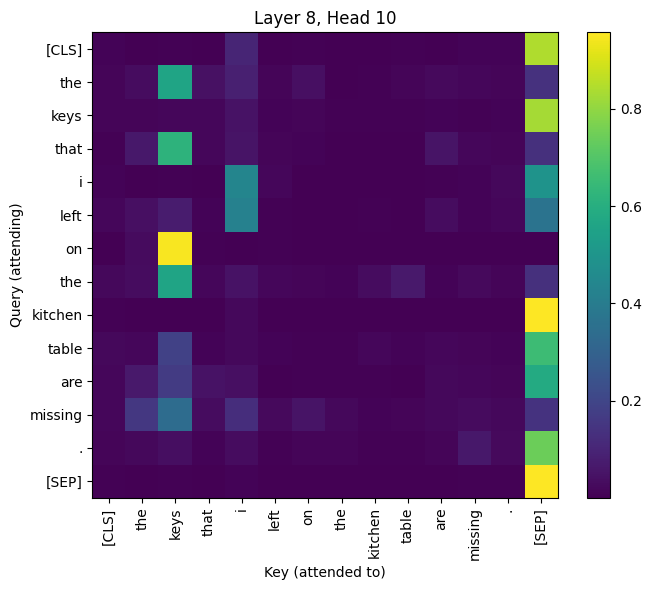

In [11]:
# 📊 FALLBACK / EXPORT — static heatmap of any single head (works everywhere, good for screenshots)
def plot_head(layer: int, head: int):
    attn = attentions[layer][0, head].numpy()
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(attn, cmap="viridis")
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens)
    ax.set_xlabel("Key (attended to)"); ax.set_ylabel("Query (attending)")
    ax.set_title(f"Layer {layer}, Head {head}")
    fig.colorbar(im, fraction=0.046)
    plt.tight_layout(); plt.show()

plot_head(layer=8, head=10)   # try different (layer, head) pairs while exploring

---
## Part 4 — Single-Head vs Multi-Head: What Different Heads Learn (5 min)

One sentence, four heads, side by side — the "many perspectives" idea from Slide 13 made visible.

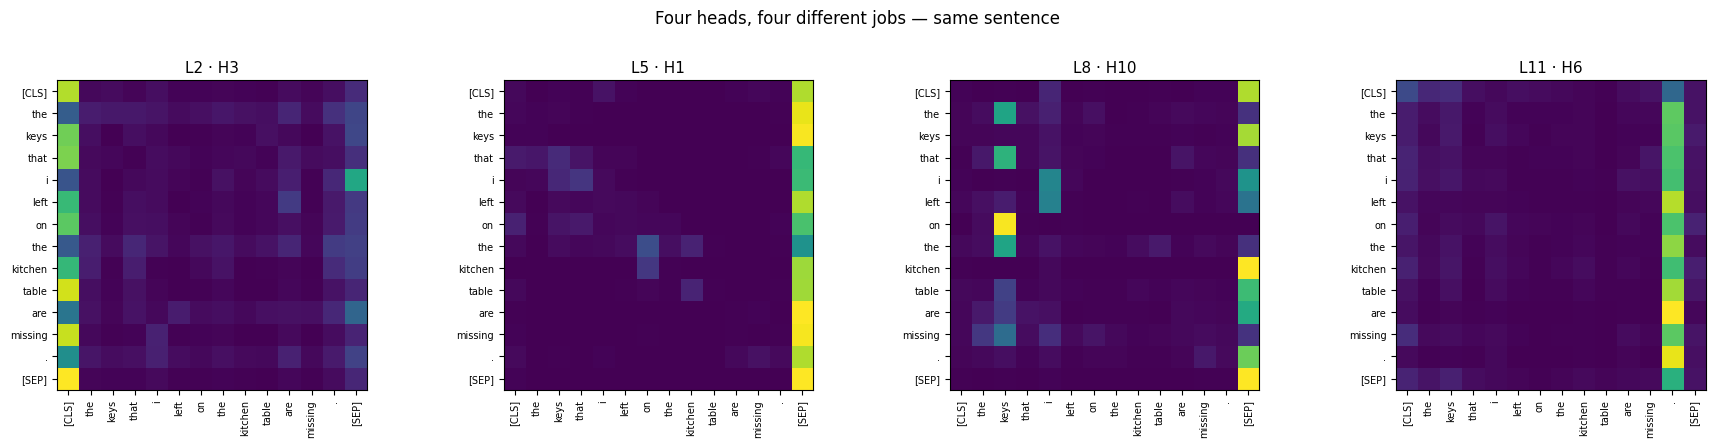

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
picks = [(2, 3), (5, 1), (8, 10), (11, 6)]   # (layer, head) — vary these!
for ax, (layer, head) in zip(axes, picks):
    attn = attentions[layer][0, head].numpy()
    ax.imshow(attn, cmap="viridis")
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f"L{layer} · H{head}", fontsize=11)
plt.suptitle("Four heads, four different jobs — same sentence", y=1.03)
plt.tight_layout(); plt.show()

**✏️ Exercise 4.1** — Adjust `picks` until you've found **one clearly positional head** and **one clearly syntactic/semantic head**. Note the (layer, head) coordinates and describe each pattern in one sentence — you'll reuse this skill directly in the assignment.

---
## 🏆 Challenges (optional, ranked)

1. **Causal masking (⭐⭐)** — GPT-style models must not attend to *future* tokens. Add a `mask` argument to `scaled_dot_product_attention` that sets future positions to `-inf` *before* softmax. Verify the weight matrix becomes lower-triangular.
2. **Attention entropy (⭐⭐)** — For every (layer, head) in BERT, compute the average entropy of its attention rows. Plot a 12×12 heatmap. Do heads become more focused (lower entropy) in deeper layers?
3. **Cross-sentence coreference (⭐⭐⭐)** — Feed `"The trophy didn't fit in the suitcase because it was too big."` Which token does `it` attend to most, per layer? Then swap **big → small** and check whether attention shifts from *trophy* to *suitcase* (a Winograd-style probe).

In [13]:
# 🏆 Challenge workspace
def scaled_dot_product_attention_masked(Q, K, V, mask=None):
    d = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)   # masked positions → ~0 weight after softmax
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

# Example causal mask for the 4-token toy input:
causal = np.tril(np.ones((4, 4), dtype=bool))
_, w = scaled_dot_product_attention_masked(Q, K, V, mask=causal)
print(np.round(w, 3))  # should be lower-triangular

[[1.    0.    0.    0.   ]
 [0.903 0.097 0.    0.   ]
 [0.748 0.064 0.188 0.   ]
 [0.095 0.495 0.178 0.233]]


---
## Summary

| Concept | What you did |
|---|---|
| Tokens & embeddings | Saw exactly what a Transformer receives — sub-word IDs → 768-dim vectors with position baked in |
| Attention computation | Implemented score → scale → softmax → blend in ~6 lines of NumPy and verified rows sum to 1 |
| The scaling step | Demonstrated why √d matters: unscaled softmax saturates at high dimension |
| Multi-head | Built a 2-head version by splitting dimensions — and saw 144 real heads in BERT |
| Reading attention | Identified positional, syntactic, and special-token head behaviors — and learned not to over-interpret them |

**Next:** keep this notebook open — the assignment ("Attention Field Report") extends Parts 3–4 with your own sentences. See the assignment brief for the rubric.

*Module 2 · Session 1 — Generative & Agentic AI Systems*